# Build the perfect Model

### Merge Dataset


🔧 Threshold: 0.50
Accuracy: 0.647
              precision    recall  f1-score   support

           0      0.692     0.834     0.757       494
           1      0.474     0.288     0.358       257

    accuracy                          0.647       751
   macro avg      0.583     0.561     0.558       751
weighted avg      0.618     0.647     0.620       751


🔧 Threshold: 0.40
Accuracy: 0.615
              precision    recall  f1-score   support

           0      0.694     0.741     0.717       494
           1      0.429     0.374     0.399       257

    accuracy                          0.615       751
   macro avg      0.562     0.557     0.558       751
weighted avg      0.603     0.615     0.608       751


🔧 Threshold: 0.35
Accuracy: 0.602
              precision    recall  f1-score   support

           0      0.700     0.690     0.695       494
           1      0.420     0.432     0.426       257

    accuracy                          0.602       751
   macro avg      0.560

<Figure size 1000x800 with 0 Axes>

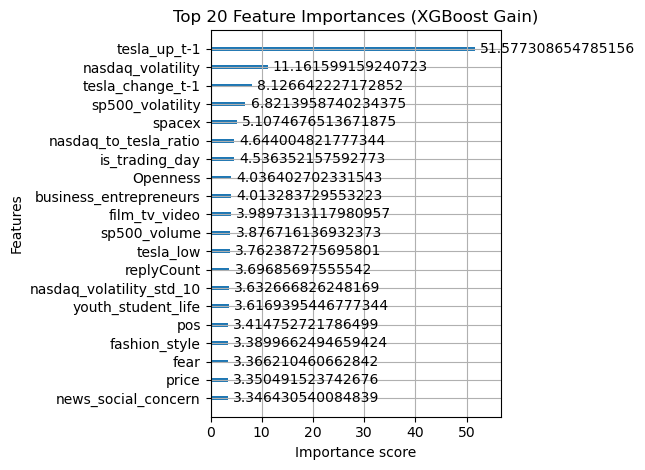

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# ─── 1. Load and merge data ────────────────────────────────────────────────────
df_twitter = pd.read_csv('../data/finance_data/processing_financeData_target_variables.csv')
df_finance = pd.read_csv('../data/twitter_data/processed/weighted_final_daily_df.csv')
df = pd.merge(df_twitter, df_finance, left_on='Date', right_on='date', how='inner')


df = df.loc[:, ~df.columns.str.contains('_t-1')]


# ─── 2. Create binary target for next-day tesla movement ───────────────────────
df['tesla_change_next'] = df['tesla_change'].shift(-1)
df = df.dropna(subset=['tesla_change_next'])
df['tesla_up'] = (df['tesla_change_next'] > 0).astype(int)

# ─── 3. Add lag features ───────────────────────────────────────────────────────
df['tesla_change_t-1'] = df['tesla_change'].shift(1)
df['tesla_up_t-1'] = (df['tesla_change_t-1'] > 0).astype(int)
df = df.dropna(subset=['tesla_change_t-1'])

# ─── 4. Prepare features ───────────────────────────────────────────────────────
drop_cols = ['tesla_change_next', 'tesla_change', 'tesla_up', 'tesla_close', 'Date', 'date']
features = df.drop(columns=[col for col in drop_cols if col in df.columns])
target = df['tesla_up']

# Cleanup: remove constant or NaN-only cols
features = features.loc[:, features.nunique(dropna=False) > 1]
features = features.dropna(axis=1, how='all').fillna(0)

# ─── 5. Time-based train/test split ────────────────────────────────────────────
cut = int(len(df) * 0.8)
X_train, X_test = features.iloc[:cut], features.iloc[cut:]
y_train, y_test = target.iloc[:cut], target.iloc[cut:]

# ─── 6. Class imbalance handling with scale_pos_weight ─────────────────────────
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_ratio = neg / pos

model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_ratio
)

model.fit(X_train, y_train)

# ─── 7. Predict with threshold tuning ──────────────────────────────────────────
y_proba = model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.35, 0.3, 0.25]:
    y_pred = (y_proba > threshold).astype(int)
    print(f"\n🔧 Threshold: {threshold:.2f}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred, digits=3))

# ─── 8. Plot top features ──────────────────────────────────────────────────────
from xgboost import plot_importance
plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=20, importance_type='gain')
plt.title("Top 20 Feature Importances (XGBoost Gain)")
plt.tight_layout()
plt.show()


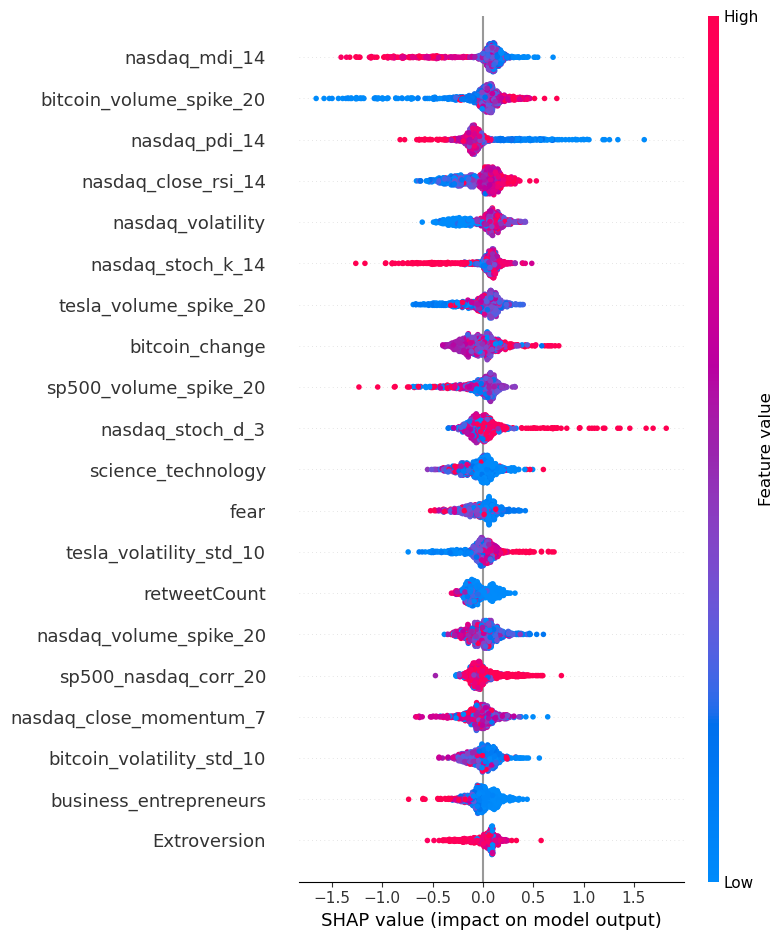

In [18]:
import shap

# SHAP init
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, max_display=20)
